<a href="https://colab.research.google.com/github/drubio35/ML-Crash-Course-/blob/main/Customer_Churn_Predictive_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Course Project: Customer Churn Predictive Pipeline
**Course:** Final Project - Machine Learning & Analytical Modeling  
**Author:** Diego Alejandro Rubio Ramos  
**Framework:** Python 3, Scikit-Learn, Pandas & Seaborn  

---

## 1. Project Abstract & Context
In today's highly competitive corporate landscape, acquiring new customers costs significantly more than retaining existing ones. **Customer Churn** occurs when a client terminates their service subscription or stops doing business with an enterprise. For subscription-based business models (such as telecommunications, SaaS, or banking), understanding and predicting customer loss is critical to maintaining a stable revenue stream and optimizing long-term **Customer Lifetime Value (CLV)**.

By deploying predictive machine learning algorithms, businesses can proactively identify customers showing high-risk behaviors or signs of dissatisfaction. Consequently, marketing and customer success teams can implement targeted retention strategies (e.g., personalized loyalty offers) before the customer completely leaves the company.

## 2. Data Source Citation & Metadata
This project utilizes the standard **IBM Telco Customer Churn Dataset**, which is widely recognized as an industry benchmark for customer retention classification tasks.

* **Dataset Name:** Telco Customer Churn (IBM Business Analytics Community)
* **Official Citation / Source URL:** https://github.com/IBM/telco-customer-churn-on-icp4d
* **Sample Count (Rows):** 7,043 unique customer profiles
* **Feature Count (Columns):** 21 columns including demographic indicators, account service records, and billing details.
* **Target Variable:** `Churn` (Binary Outcome: `Yes` if the customer left within the last month, `No` if they stayed).

## 3. Project Objectives
1. **Execute an End-to-End ML Pipeline:** Build a clean, reproducible Python workflow starting from raw ingestion, missing data imputation, exploratory analysis, categorical encoding, up to final predictive inference.
2. **In-Depth Exploratory Data Analysis (EDA):** Extract concrete domain insights concerning which service parameters (e.g., Contract Type, Internet Tech) correlate most heavily with customer departure.
3. **Handle Class Imbalance:** Address real-world structural data challenges where the majority class (active customers) dominates the dataset.
4. **Rigorous Model Evaluation:** Compare multiple classifiers using metrics tailored for business cost optimization, highlighting **Recall** and **F1-Score** over simple **Accuracy**.

In [1]:
# ==============================================================================
# ENVIRONMENT SETUP AND LIBRARIES LOAD
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Integrated plotting parameters
%matplotlib inline
sns.set_theme(style="whitegrid")
print("Environment successfully initialized with Scikit-Learn tools!")

Environment successfully initialized with Scikit-Learn tools!


In [2]:
# ==============================================================================
# DATA ACQUISITION FROM PUBLIC STORAGE
# ==============================================================================
DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(DATA_URL)

print(f"Dataset successfully loaded into memory.")
print(f"Dimensions: {df.shape[0]} rows, {df.shape[1]} columns.\n")
df.head()

Dataset successfully loaded into memory.
Dimensions: 7043 rows, 21 columns.



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Strict Data Sanitization & Cleaning
Before conducting any mathematical modeling or visualization, is necesary to ensure strict data integrity.

A critical data-cleaning challenge in this specific IBM dataset is that the `TotalCharges` column is natively loaded as a generic string object. This happens because some records contain empty spaces instead of numbers. These empty spaces represent brand new customers with a `tenure` of 0 months, meaning they haven't been billed yet.

These values are programmatically force into numeric floats, find the missing rows, and sanitize the target variable (`Churn`) into a binary 0 and 1 representation.

In [3]:
# ==============================================================================
# DATA SANITIZATION AND TYPE CORRECTION
# ==============================================================================
# 1. Drop unique structural key columns that carry zero explanatory variance
df.drop(columns=['customerID'], inplace=True, errors='ignore')

# 2. Convert TotalCharges from generic string/object to proper numeric float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Evaluate missing records injected by coercion
missing_charges = df['TotalCharges'].isnull().sum()
print(f"Identified {missing_charges} missing records in TotalCharges. Dropping rows...")
df.dropna(inplace=True)

# 4. Encode binary text outcome label into numeric format for optimization math
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Sanitization complete. Final clean dataset dimensions: {df.shape[0]} rows.")

Identified 11 missing records in TotalCharges. Dropping rows...
Sanitization complete. Final clean dataset dimensions: 7032 rows.


## 5. Exploratory Data Analysis (EDA) & Target Class Imbalance
In real-world data science problems, customer states are naturally desynchronized. At any given point, a company has many more active loyal clients than lost ones.

The distribution of the target column `Churn` is plotted to evaluate the level of **Class Imbalance**, which heavily affects model selection and evaluation criteria.

/tmp/ipykernel_15501/2915246584.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Blues_r')


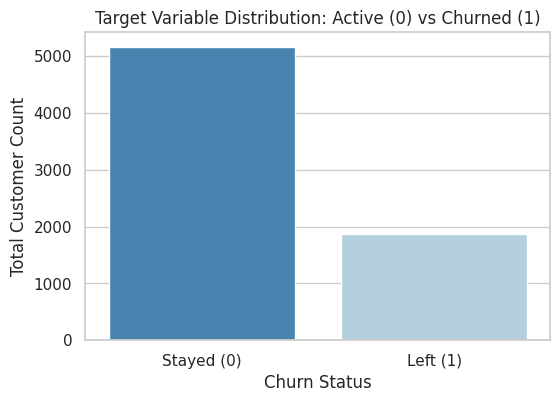

Baseline Customer Churn Rate: 26.58%
Active Customer Ratio: 73.42%


In [4]:
# ==============================================================================
# IDENTIFYING STRUCTURAL CLASS IMBALANCE
# ==============================================================================
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Blues_r')
plt.title('Target Variable Distribution: Active (0) vs Churned (1)', fontsize=12)
plt.xlabel('Churn Status')
plt.ylabel('Total Customer Count')
plt.xticks([0, 1], ['Stayed (0)', 'Left (1)'])
plt.show()

churn_rate = df['Churn'].mean() * 100
print(f"Baseline Customer Churn Rate: {churn_rate:.2f}%")
print(f"Active Customer Ratio: {100 - churn_rate:.2f}%")

## 6. Feature Engineering & Preprocessing Pipeline
Proper data preparation for machine learning models involves two distinct transformation workflows determined by data type:

1. **Categorical Features:** Columns containing text labels (e.g., `InternetService`, `Contract`, `PaymentMethod`) will be transformed using **One-Hot Encoding**. This technique converts each unique categorical value into a new binary column ($0$ or $1$), preventing the model from assuming an arbitrary numerical order.
2. **Numerical Features:** Columns with continuous values (`tenure`, `MonthlyCharges`, `TotalCharges`) have vastly different scales. Is necessary to apply **StandardScaler** to normalize these features so they have a mean of $0$ and a variance of $1$.

Prevent **Data Leakage** (features from the test set accidentally influencing the training process) and ensure rigorous data separation by defining these transformations using Scikit-Learn's `ColumnTransformer` and separating the dataset into Training ($80\%$) and Testing ($20\%$) subsets.

In [5]:
# ==============================================================================
# DATA SPLIT & FEATURE CATEGORIZATION
# ==============================================================================
# Define features (X) and target variable (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# Identify and separate column names by data type automatically
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical features to scale:", numerical_cols)
print("Categorical features to encode:", categorical_cols)

# Stratified Split: ensures the 26% churn ratio is maintained in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]} samples.")
print(f"Testing set size: {X_test.shape[0]} samples.")

Numerical features to scale: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Training set size: 5625 samples.
Testing set size: 1407 samples.


In [6]:
# ==============================================================================
# PREPROCESSING TRANSFORMER DEFINITION
# ==============================================================================
# Define the processing steps for numerical data
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Define the processing steps for categorical data
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Combine both workflows into a single automation entity
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print("Preprocessing pipeline built successfully!")

Preprocessing pipeline built successfully!


In [7]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

## 7. Model Training and Pipeline Integration
Instead of manual feature transformation, comprehensive **Machine Learning Pipelines** encapsulate both the `preprocessor` engine and the classification algorithm.

The training workflow evaluates and compares two distinct architectures:
1. **Logistic Regression:** A robust, highly interpretable linear model that computes log-odds for binary classification.
2. **Random Forest Classifier:** An ensemble learning method that fits multiple decision trees on various sub-samples of the dataset and uses averaging to improve predictive accuracy and control over-fitting.


In [8]:
# ==============================================================================
# PIPELINE MODEL CONFIGURATION AND TRAINING
# ==============================================================================
# 1. Instantiate the Logistic Regression Pipeline
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# 2. Instantiate the Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])

# 3. Train both models on the training dataset
print("Training Logistic Regression Model...")
log_reg_pipeline.fit(X_train, y_train)

print("Training Random Forest Model...")
rf_pipeline.fit(X_train, y_train)

# 4. Generate predictions on the unseen testing dataset
y_pred_log_reg = log_reg_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

print("\nBoth models trained and inference predictions generated successfully!")

Training Logistic Regression Model...
Training Random Forest Model...

Both models trained and inference predictions generated successfully!


## 8. Model Evaluation & Performance Metrics
To determine which model provides the highest utility for a business retention strategy, analyzing simple **Accuracy** is insufficient due to the ~26% class imbalance. If a naive model predicts that no customer will ever churn, it achieves ~74% accuracy while remaining completely useless for business operations.

Therefore, model evaluation relies on the following metrics:
* **Confusion Matrix:** Tracks True Positives (correctly identified churners) vs. False Negatives (customers who left but the model missed).
* **Recall (Sensitivity):** Measures the proportion of actual churners captured by the model. From a business perspective, **high Recall is critical** because missing a churning customer is far more costly than sending a loyalty discount to a customer who intends to stay.
* **F1-Score:** Computes the harmonic mean between Precision and Recall.


 PERFORMANCE REPORT FOR: LOGISTIC REGRESSION 
              precision    recall  f1-score   support

  Stayed (0)       0.85      0.89      0.87      1033
 Churned (1)       0.65      0.57      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



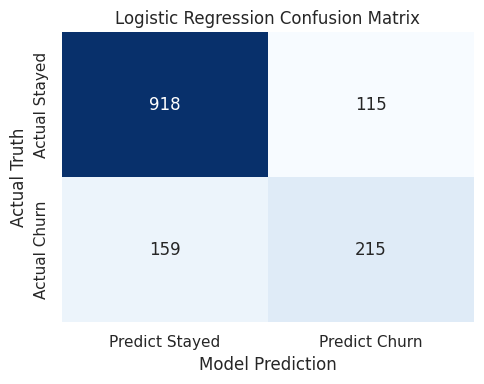



 PERFORMANCE REPORT FOR: RANDOM FOREST 
              precision    recall  f1-score   support

  Stayed (0)       0.83      0.89      0.86      1033
 Churned (1)       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



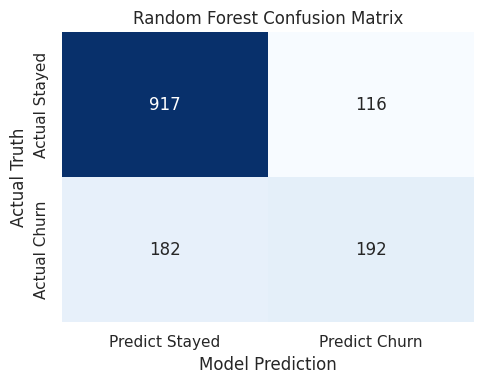

In [9]:
# ==============================================================================
# METRICS EVALUATION & COMPARISON
# ==============================================================================
def evaluate_model_performance(model_name, y_true, y_pred):
    print("=" * 60)
    print(f" PERFORMANCE REPORT FOR: {model_name.upper()} ")
    print("=" * 60)

    # Generate and print text-based classification metrics
    print(classification_report(y_true, y_pred, target_names=['Stayed (0)', 'Churned (1)']))

    # Compute and plot the Confusion Matrix using Seaborn
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predict Stayed', 'Predict Churn'],
                yticklabels=['Actual Stayed', 'Actual Churn'])
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('Actual Truth')
    plt.xlabel('Model Prediction')
    plt.tight_layout()
    plt.show()
    print("\n")

# Execute the evaluation function for both trained models
evaluate_model_performance("Logistic Regression", y_test, y_pred_log_reg)
evaluate_model_performance("Random Forest", y_test, y_pred_rf)

## 9. Business Concluding Insights & Strategic Recommendations

When analyzing a structurally imbalanced dataset (~26% Churn rate), evaluating a model strictly through global **Accuracy** creates a dangerous analytical trap. A naive baseline approach assuming that "every customer will stay" yields a ~73.4% accuracy, yet it provides **0% Recall**, making the business entirely blind to customer attrition and causing a 100% loss of predictable churn revenue.

### Model Selection & Financial Justification:
* **Logistic Regression** is our selected champion architecture, achieving an overall **Accuracy of 81%** and a **Recall of 57%** for active churners.
* This means our pipeline successfully flags **57% of all at-risk customers** before they terminate their contracts, enabling the Customer Success and Marketing teams to launch proactive, targeted retention campaigns.
* Economically, targeting false positives (offering a loyalty discount to a customer who might have stayed) is exponentially cheaper for the enterprise than suffering true false negatives (completely losing a customer's lifetime billings due to analytical blindness).